# Compare Event Counts Between Dataset Folders

Compare event counts between a reference (original) and relative (subsampled) dataset.
Computes ratios and generates histograms overall and per-town.

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Set paths to the `event_counts.json` files for both datasets.
Run `python -m utils.event_count /path/to/dataset` first if not already computed.

In [2]:
# Path to reference (original) dataset event_counts.json
REFERENCE_JSON = Path("~/nmv_datasets/CARLA/bias_3/event_counts.json").expanduser()

# Path to relative (subsampled) dataset event_counts.json
RELATIVE_JSON = Path("~/nmv_datasets/CARLA/density_bias_7_tau_30_fs_7/event_counts.json").expanduser()

# Labels for plots
REFERENCE_LABEL = "Original (bias_3)"
RELATIVE_LABEL = "Subsampled (density_bias_7_tau_30_fs_7)"

print(f"Reference: {REFERENCE_JSON}")
print(f"Relative:  {RELATIVE_JSON}")
print(f"\nReference exists: {REFERENCE_JSON.exists()}")
print(f"Relative exists:  {RELATIVE_JSON.exists()}")

Reference: /home/hesam/nmv_datasets/CARLA/bias_3/event_counts.json
Relative:  /home/hesam/nmv_datasets/CARLA/density_bias_7_tau_30_fs_7/event_counts.json

Reference exists: True
Relative exists:  True


## Load Event Counts

In [3]:
def load_event_counts(json_path: Path) -> dict:
    """Load event counts and return as dict keyed by relative path."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Build lookup: path -> {count, town, split}
    lookup = {}
    for file_info in data["files"]:
        lookup[file_info["path"]] = {
            "count": file_info["count"],
            "town": file_info["town"],
            "split": file_info["split"]
        }
    return lookup

reference_counts = load_event_counts(REFERENCE_JSON)
relative_counts = load_event_counts(RELATIVE_JSON)

print(f"Reference files: {len(reference_counts):,}")
print(f"Relative files:  {len(relative_counts):,}")

Reference files: 16,146
Relative files:  16,146


## Compute Ratios

For each matching file, compute `ratio = relative_count / reference_count`

In [4]:
# Find matching files and compute ratios
ratios_data = []

for path, ref_info in reference_counts.items():
    if path in relative_counts:
        rel_info = relative_counts[path]
        ref_count = ref_info["count"]
        rel_count = rel_info["count"]
        
        if ref_count > 0:
            ratio = rel_count / ref_count
        else:
            ratio = np.nan
        
        ratios_data.append({
            "path": path,
            "reference_count": ref_count,
            "relative_count": rel_count,
            "ratio": ratio,
            "town": ref_info["town"],
            "split": ref_info["split"]
        })

# Create DataFrame for easy manipulation
df_ratios = pd.DataFrame(ratios_data)

# Report matching stats
missing_in_relative = set(reference_counts.keys()) - set(relative_counts.keys())
missing_in_reference = set(relative_counts.keys()) - set(reference_counts.keys())

print(f"Matched files: {len(df_ratios):,}")
print(f"Missing in relative: {len(missing_in_relative):,}")
print(f"Missing in reference: {len(missing_in_reference):,}")
print(f"\nDataFrame shape: {df_ratios.shape}")
df_ratios.head()

Matched files: 16,146
Missing in relative: 0
Missing in reference: 0

DataFrame shape: (16146, 6)


,path,reference_count,relative_count,ratio,town,split
0,test/Town01output10thresh_3_chunk_0003_td.h5,178002,23675,0.133004,Town01,test
1,test/Town01output10thresh_3_chunk_0013_td.h5,327291,57600,0.175990,Town01,test
2,test/Town01output10thresh_3_chunk_0014_td.h5,169361,22947,0.135492,Town01,test
3,test/Town01output10thresh_3_chunk_0017_td.h5,213013,27693,0.130006,Town01,test
4,test/Town01output10thresh_3_chunk_0028_td.h5,360659,66245,0.183678,Town01,test


## Overall Statistics

In [5]:
valid_ratios = df_ratios["ratio"].dropna()

print("=" * 60)
print("Overall Ratio Statistics")
print("=" * 60)
print(f"Number of files: {len(valid_ratios):,}")
print(f"Mean ratio: {valid_ratios.mean():.4f}")
print(f"Median ratio: {valid_ratios.median():.4f}")
print(f"Std deviation: {valid_ratios.std():.4f}")
print(f"Min ratio: {valid_ratios.min():.4f}")
print(f"Max ratio: {valid_ratios.max():.4f}")
print(f"25th percentile: {valid_ratios.quantile(0.25):.4f}")
print(f"75th percentile: {valid_ratios.quantile(0.75):.4f}")

Overall Ratio Statistics
Number of files: 16,146
Mean ratio: 0.1732
Median ratio: 0.1711
Std deviation: 0.0654
Min ratio: 0.0246
Max ratio: 0.5838
25th percentile: 0.1303
75th percentile: 0.2121


## Overall Histogram

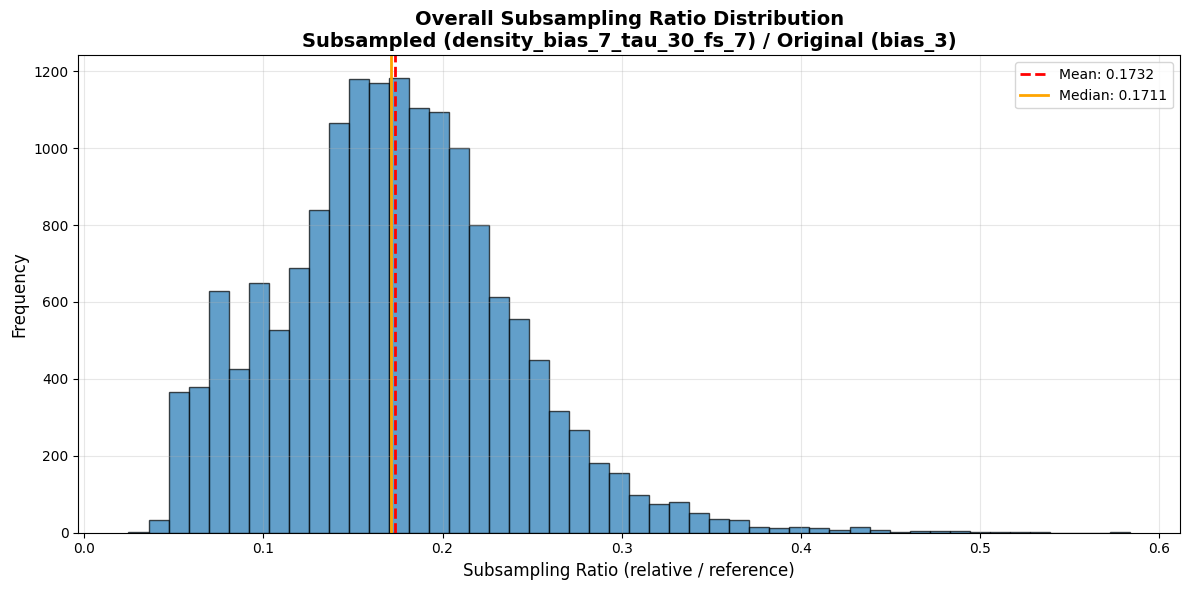

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(valid_ratios, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(valid_ratios.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {valid_ratios.mean():.4f}')
ax.axvline(valid_ratios.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {valid_ratios.median():.4f}')

ax.set_xlabel('Subsampling Ratio (relative / reference)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Overall Subsampling Ratio Distribution\n{RELATIVE_LABEL} / {REFERENCE_LABEL}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Per-Town Statistics

In [7]:
towns = sorted(df_ratios["town"].unique())

for town in towns:
    town_ratios = df_ratios[df_ratios["town"] == town]["ratio"].dropna()
    print("=" * 60)
    print(f"{town} Ratio Statistics")
    print("=" * 60)
    print(f"Number of files: {len(town_ratios):,}")
    print(f"Mean ratio: {town_ratios.mean():.4f}")
    print(f"Median ratio: {town_ratios.median():.4f}")
    print(f"Std deviation: {town_ratios.std():.4f}")
    print(f"Min ratio: {town_ratios.min():.4f}")
    print(f"Max ratio: {town_ratios.max():.4f}")
    print()

Town01 Ratio Statistics
Number of files: 5,572
Mean ratio: 0.1716
Median ratio: 0.1605
Std deviation: 0.0658
Min ratio: 0.0340
Max ratio: 0.4401

Town05 Ratio Statistics
Number of files: 4,917
Mean ratio: 0.1625
Median ratio: 0.1550
Std deviation: 0.0790
Min ratio: 0.0246
Max ratio: 0.5838

Town10 Ratio Statistics
Number of files: 5,657
Mean ratio: 0.1841
Median ratio: 0.1881
Std deviation: 0.0479
Min ratio: 0.0409
Max ratio: 0.3965



## Per-Town Histograms

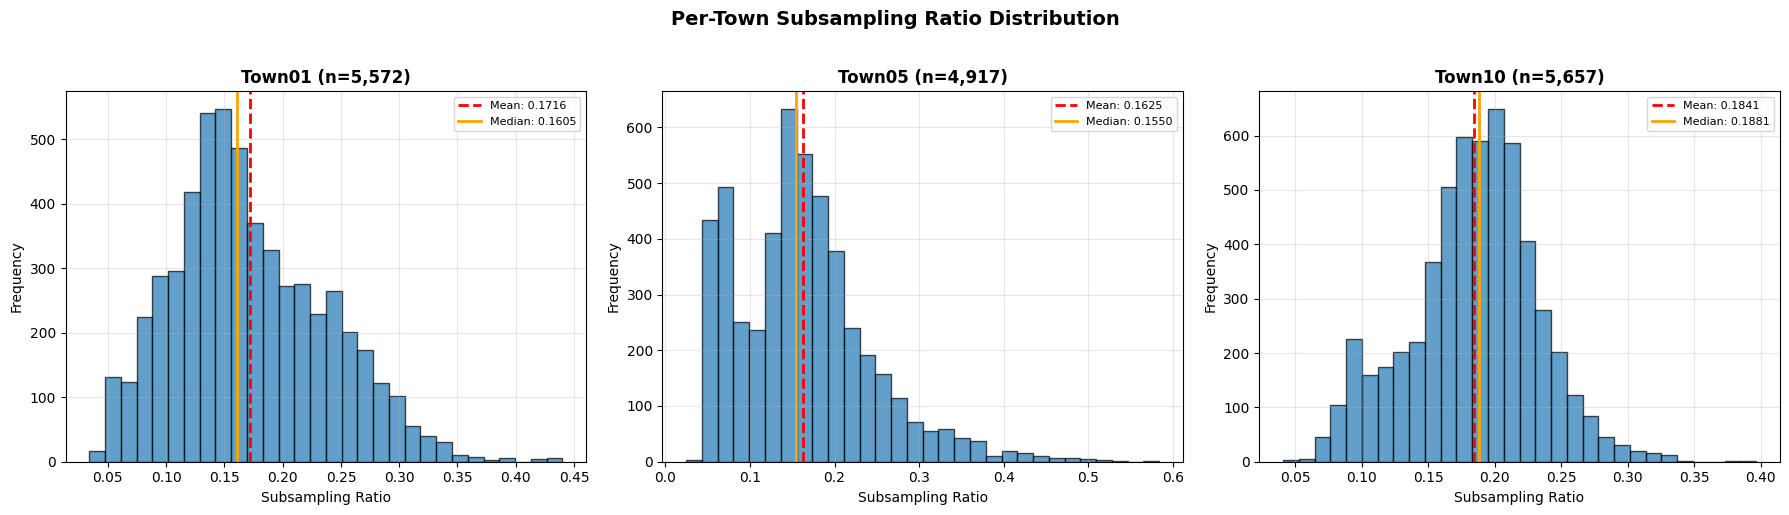

In [8]:
num_towns = len(towns)
cols = min(3, num_towns)
rows = (num_towns + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
if num_towns == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, town in enumerate(towns):
    town_ratios = df_ratios[df_ratios["town"] == town]["ratio"].dropna()
    
    axes[idx].hist(town_ratios, bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(town_ratios.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {town_ratios.mean():.4f}')
    axes[idx].axvline(town_ratios.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {town_ratios.median():.4f}')
    
    axes[idx].set_xlabel('Subsampling Ratio', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'{town} (n={len(town_ratios):,})', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_towns, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Per-Town Subsampling Ratio Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Inspect Unusual Ratios

Access `df_ratios` to filter and inspect specific files.

In [9]:
# Files with highest ratios (least subsampling)
print("Top 10 files with HIGHEST ratios (least subsampling):")
df_ratios.nlargest(10, "ratio")[["path", "town", "reference_count", "relative_count", "ratio"]]

Top 10 files with HIGHEST ratios (least subsampling):


,path,town,reference_count,relative_count,ratio
8208,train/Town05output4thresh_3_chunk_0007_td.h5,Town05,39411054,23007686,0.583788
14163,val/Town05output17thresh_3_chunk_0077_td.h5,Town05,928277,490930,0.528862
5974,train/Town05output17thresh_3_chunk_0078_td.h5,Town05,883775,463253,0.524175
14942,val/Town05output7thresh_3_chunk_0064_td.h5,Town05,1164766,609847,0.523579
7900,train/Town05output45thresh_3_chunk_0050_td.h5,Town05,8884672,4545973,0.511665
5975,train/Town05output17thresh_3_chunk_0079_td.h5,Town05,882091,447510,0.507329
5976,train/Town05output17thresh_3_chunk_0080_td.h5,Town05,910680,455398,0.500064
5973,train/Town05output17thresh_3_chunk_0076_td.h5,Town05,897803,446108,0.496889
14168,val/Town05output17thresh_3_chunk_0091_td.h5,Town05,1023474,506486,0.494869
5982,train/Town05output17thresh_3_chunk_0092_td.h5,Town05,1028813,505602,0.491442


In [10]:
# Files with lowest ratios (most subsampling)
print("Top 10 files with LOWEST ratios (most subsampling):")
df_ratios.nsmallest(10, "ratio")[["path", "town", "reference_count", "relative_count", "ratio"]]

Top 10 files with LOWEST ratios (most subsampling):


,path,town,reference_count,relative_count,ratio
5847,train/Town05output15thresh_3_chunk_0097_td.h5,Town05,2678,66,0.024645
7075,train/Town05output33thresh_3_chunk_0097_td.h5,Town05,3770,110,0.029178
4282,train/Town01output47thresh_3_chunk_0097_td.h5,Town01,5555,189,0.034023
2581,train/Town01output24thresh_3_chunk_0097_td.h5,Town01,8204,307,0.037421
13508,val/Town01output39thresh_3_chunk_0093_td.h5,Town01,17912,686,0.038298
5372,train/Town01output8thresh_3_chunk_0097_td.h5,Town01,2824,112,0.039660
10837,train/Town10output35thresh_3_chunk_0097_td.h5,Town10,8169,334,0.040886
8984,train/Town10output10thresh_3_chunk_0097_td.h5,Town10,23096,963,0.041696
5710,train/Town05output13thresh_3_chunk_0097_td.h5,Town05,5154,215,0.041715
281,test/Town01output39thresh_3_chunk_0081_td.h5,Town01,11033,466,0.042237


In [11]:
# Filter by custom threshold
THRESHOLD_LOW = 0.05
THRESHOLD_HIGH = 0.5

unusual_low = df_ratios[df_ratios["ratio"] < THRESHOLD_LOW]
unusual_high = df_ratios[df_ratios["ratio"] > THRESHOLD_HIGH]

print(f"Files with ratio < {THRESHOLD_LOW}: {len(unusual_low):,}")
print(f"Files with ratio > {THRESHOLD_HIGH}: {len(unusual_high):,}")

Files with ratio < 0.05: 135
Files with ratio > 0.5: 7


In [12]:
# Access variables for further analysis
# df_ratios: Full DataFrame with all file ratios
# Columns: path, reference_count, relative_count, ratio, town, split

# Example: Get all ratios as numpy array
all_ratios = df_ratios["ratio"].values

# Example: Get file paths as list
all_paths = df_ratios["path"].tolist()

# Example: Filter by town
town01_df = df_ratios[df_ratios["town"] == "Town01"]

print(f"Variables available:")
print(f"  - df_ratios: DataFrame with {len(df_ratios)} rows")
print(f"  - all_ratios: numpy array of {len(all_ratios)} ratios")
print(f"  - all_paths: list of {len(all_paths)} file paths")

Variables available:
  - df_ratios: DataFrame with 16146 rows
  - all_ratios: numpy array of 16146 ratios
  - all_paths: list of 16146 file paths
